# Análisis Multivariado de Planta Fotovoltaica
## Institución Educativa – Malambo, Atlántico (Colombia)

---

| Campo | Detalle |
|---|---|
| **Programa** | Maestría en Gestión Energética - Universidad del Atlántico |
| **Sistema fotovoltaico** | 4 × Trina Solar TSM-540 DEG18MC.20(II) |
| **Inversor** | Microinversor Hoymiles (monitoreo en la nube) |
| **Proxy meteorológico** | Aeropuerto Internacional Ernesto Cortissoz (IATA: BAQ) |
| **Período de análisis** | 17 de abril – 08 de mayo de 2026 (22 días) |
| **Total de registros** | 1 136 (frecuencia mixta: 15 min predominante) |

---

### Pregunta de investigación
> *¿En qué medida las variables meteorológicas registradas en el Aeropuerto Ernesto Cortissoz (temperatura y humedad relativa) explican la diferencia entre la potencia teórica estimada mediante el modelo físico del diodo y la potencia real medida por el inversor Hoymiles en la Institución Educativa de Malambo?*
---

### Estructura del notebook
1. Configuración e importaciones
2. Carga y exploración de datos (EDA)
3. Pruebas de normalidad
4. Modelo físico del diodo único (pvlib)
5. Validación: Real vs. Teórico
6. Análisis correlacional: Pearson y Spearman
7. Regresión OLS multivariada
8. Métricas de error del modelo
9. Diagnóstico de residuos
10. Modelado Avanzado: Machine Learning No Lineal
11. Evaluación Visual: Residuos y Series Temporales
12. Conclusiones y Recomendaciones

---
## 1. Configuración e Importaciones

> **Nota metodológica:** Se utiliza `pvlib` (De Soto et al., 2006) para el modelo físico del diodo, `statsmodels` para la regresión OLS con estadísticos robustos, y `scipy.stats` para las pruebas de normalidad. Se trabaja con una ruta relativa para garantizar la reproducibilidad del notebook en cualquier equipo.

In [1]:
# -- Instalacion condicional de dependencias -----------------------------------
import sys, subprocess

def instalar_si_falta(paquete):
    try:
        __import__(paquete)
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', paquete, '-q'])

# Agregamos dependencias necesarias
for pkg in ['pvlib', 'statsmodels', 'scikit-learn', 'scipy', 'openpyxl', 'xgboost']:
    instalar_si_falta(pkg)

# -- Importaciones -------------------------------------------------------------
import os, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# Configuracion de visualizacion
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['font.size'] = 11

# Directorio para guardar graficas
os.makedirs('../visuals', exist_ok=True)

def save_vis(name):
    plt.savefig(f'../visuals/{name}', dpi=300, bbox_inches='tight')
    print(f"Gráfica guardada en: visuals/{name}")

print("Entorno configurado correctamente.")

Entorno configurado correctamente.


---
## 2. Carga y Exploración de Datos (EDA)

> **Nota sobre las fuentes de datos:**
> - `pv_power`: medición directa del inversor Hoymiles vía plataforma cloud. **Dato real de campo.**
> - `irradiancia_estimada_Wm2`: **proxy derivado** a partir de registros METAR del Aeropuerto Cortissoz, convertidos a W/m² mediante factores de conversión de cobertura nubosa (oktas). No es una medición directa de piranómetro — esta distinción es crítica para interpretar los errores del modelo.
> - `temperatura_C` y `humedad_%`: registros horarios de la estación meteorológica del aeropuerto, interpolados a la resolución de 15 min del inversor.

In [2]:
N_PANELES = 4
RUTA_DATOS = '../csv/ANALISIS_SOLAR_UNIFICADO.xlsx'
# ── Carga ─────────────────────────────────────────────────────────────────────
if not os.path.exists(RUTA_DATOS):
    raise FileNotFoundError(
        f'Archivo no encontrado: "{RUTA_DATOS}"\n'
        f'Colócalo en la misma carpeta que este notebook.'
    )

df = pd.read_excel(RUTA_DATOS)
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values('timestamp').reset_index(drop=True)
df['hora'] = df['timestamp'].dt.hour
df['fecha'] = df['timestamp'].dt.date

# Columna de potencia teórica total (ya calculada en el Excel previo)
# Si no existiera se recalcularía aquí:
if 'p_teorica_total' not in df.columns:
    df['p_teorica_total'] = df['potencia_teorica_diodo'] * N_PANELES

n_total  = len(df)
n_dias   = df['fecha'].nunique()
n_diurno = (df['irradiancia_estimada_Wm2'] > 1).sum()

print('══════════════════════════════════════════')
print(f'  Registros totales   : {n_total:,}')
print(f'  Días únicos         : {n_dias}')
print(f'  Período             : {df.timestamp.min().date()} → {df.timestamp.max().date()}')
print(f'  Registros diurnos   : {n_diurno:,}  (irradiancia > 1 W/m²)')
print(f'  Registros nocturnos : {n_total - n_diurno:,}')
print('══════════════════════════════════════════')

══════════════════════════════════════════
  Registros totales   : 1,136
  Días únicos         : 22
  Período             : 2026-04-17 → 2026-05-08
  Registros diurnos   : 890  (irradiancia > 1 W/m²)
  Registros nocturnos : 246
══════════════════════════════════════════


In [3]:
# ── Resumen estadístico descriptivo ──────────────────────────────────────────
cols_num = ['pv_power', 'temperatura_C', 'humedad_%',
            'irradiancia_estimada_Wm2', 'viento_m_s', 'uv_index']
df[cols_num].describe().round(2)

,pv_power,temperatura_C,humedad_%,irradiancia_estimada_Wm2,viento_m_s,uv_index
count,1136.00,1136.00,1136.00,1136.00,1136.00,1136.00
mean,304.58,29.69,74.13,82.24,13.09,4.28
std,339.97,2.40,11.38,76.28,5.11,3.86
min,0.00,24.00,49.00,0.00,2.67,0.00
25%,44.75,28.00,64.00,8.75,9.00,0.50
50%,169.00,29.50,74.00,67.50,13.00,3.50
75%,490.00,31.67,84.00,148.75,17.00,8.00
max,1413.00,36.00,100.00,350.00,28.00,14.00


### 2.1. Análisis Estacional Horario e Incertidumbre
Analizaremos la distribución de la irradiancia proxy por franjas horarias para identificar la variabilidad del recurso.

Gráfica guardada en: visuals/analisis_irradiancia_zonas_detallado.png


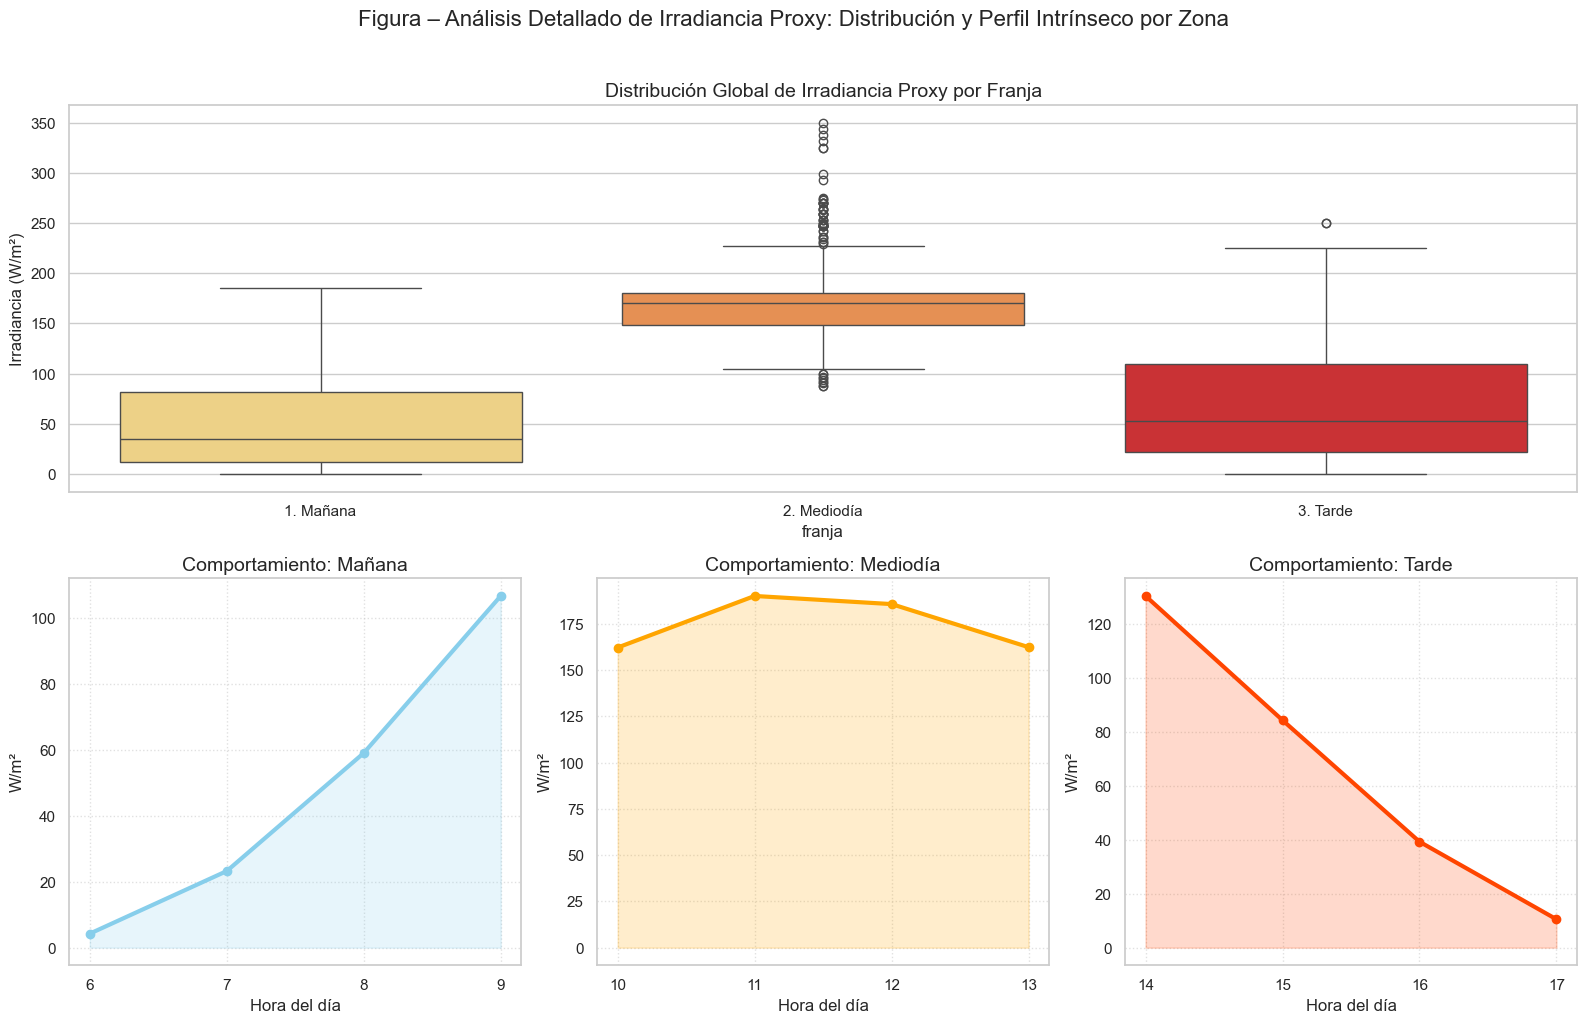

In [4]:
def categorizar_franja(h):
    if 6 <= h < 10: return '1. Mañana'
    elif 10 <= h < 14: return '2. Mediodía'
    elif 14 <= h < 18: return '3. Tarde'
    else: return '4. Noche'

df['franja'] = df['hora'].apply(categorizar_franja)
df_diurno = df[df['franja'] != '4. Noche'].copy()

# Configuración de la figura con subplots complejos
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(2, 3)

# 1. Diagrama de Caja y Bigotes (Ocupa la fila superior)
ax_box = fig.add_subplot(gs[0, :])
sns.boxplot(ax=ax_box, x='franja', y='irradiancia_estimada_Wm2', data=df_diurno, palette='YlOrRd')
ax_box.set_title('Distribución Global de Irradiancia Proxy por Franja')
ax_box.set_ylabel('Irradiancia (W/m²)')

# 2. Gráficos de Línea Independientes por Zona (Fila inferior)
franjas = ['1. Mañana', '2. Mediodía', '3. Tarde']
colores = ['skyblue', 'orange', 'orangered']

for i, franja in enumerate(franjas):
    ax = fig.add_subplot(gs[1, i])
    data_f = df_diurno[df_diurno['franja'] == franja]
    # Perfil horario promedio dentro de la franja
    perfil_f = data_f.groupby('hora')['irradiancia_estimada_Wm2'].mean()
    ax.plot(perfil_f.index, perfil_f.values, marker='o', color=colores[i], linewidth=3)
    ax.fill_between(perfil_f.index, perfil_f.values, alpha=0.2, color=colores[i])
    
    ax.set_title(f'Comportamiento: {franja.split(". ")[1]}')
    ax.set_xlabel('Hora del día')
    ax.set_ylabel('W/m²')
    ax.set_xticks(perfil_f.index)
    ax.grid(True, linestyle=':', alpha=0.6)

plt.suptitle('Figura – Análisis Detallado de Irradiancia Proxy: Distribución y Perfil Intrínseco por Zona', fontsize=16, y=1.02)
plt.tight_layout()
save_vis('analisis_irradiancia_zonas_detallado.png')
plt.show()

### 2.2. Consistencia de la Generación (Multi-día)
Se presentan 6 días de operación para demostrar que el comportamiento observado (Real > Teórico) es una constante del sistema y no un evento aislado.

Gráfica guardada en: visuals/fig5_multidia_real_teorica.png


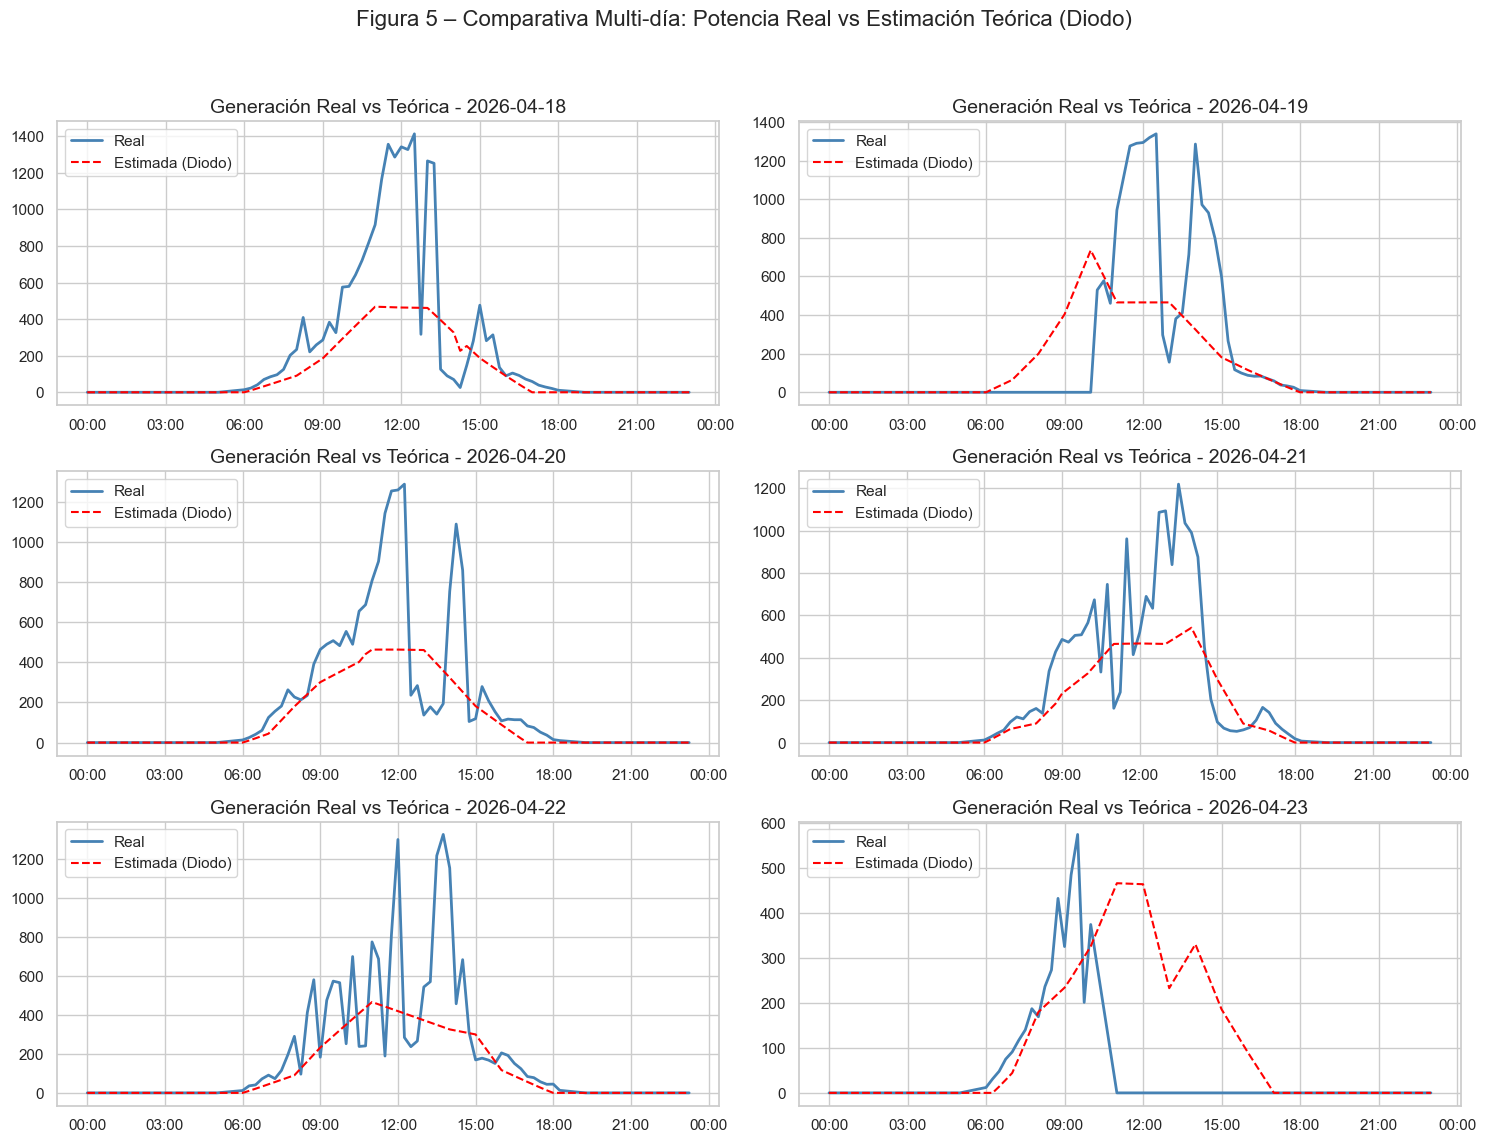

In [5]:
dias_unicos = df['fecha'].unique()
# Seleccionamos 6 días representativos
dias_muestra = dias_unicos[1:7] 

fig, axes = plt.subplots(3, 2, figsize=(15, 12))
axes = axes.flatten()

for i, d in enumerate(dias_muestra):
    temp_df = df[df['fecha'] == d]
    axes[i].plot(temp_df['timestamp'], temp_df['pv_power'], label='Real', color='steelblue', linewidth=2)
    axes[i].plot(temp_df['timestamp'], temp_df['p_teorica_total'], label='Estimada (Diodo)', color='red', linestyle='--')
    axes[i].set_title(f'Generación Real vs Teórica - {d}')
    axes[i].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    axes[i].legend(loc='upper left')

plt.suptitle('Figura 5 – Comparativa Multi-día: Potencia Real vs Estimación Teórica (Diodo)', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
save_vis('fig5_multidia_real_teorica.png')
plt.show()

### 2.3. Sincronización Temporal Multi-día (Figura 6 Extendida)
Validación de la correlación temporal entre la irradiancia proxy y la potencia real en múltiples jornadas.

Gráfica guardada en: visuals/fig6_multidia_sincronizacion.png


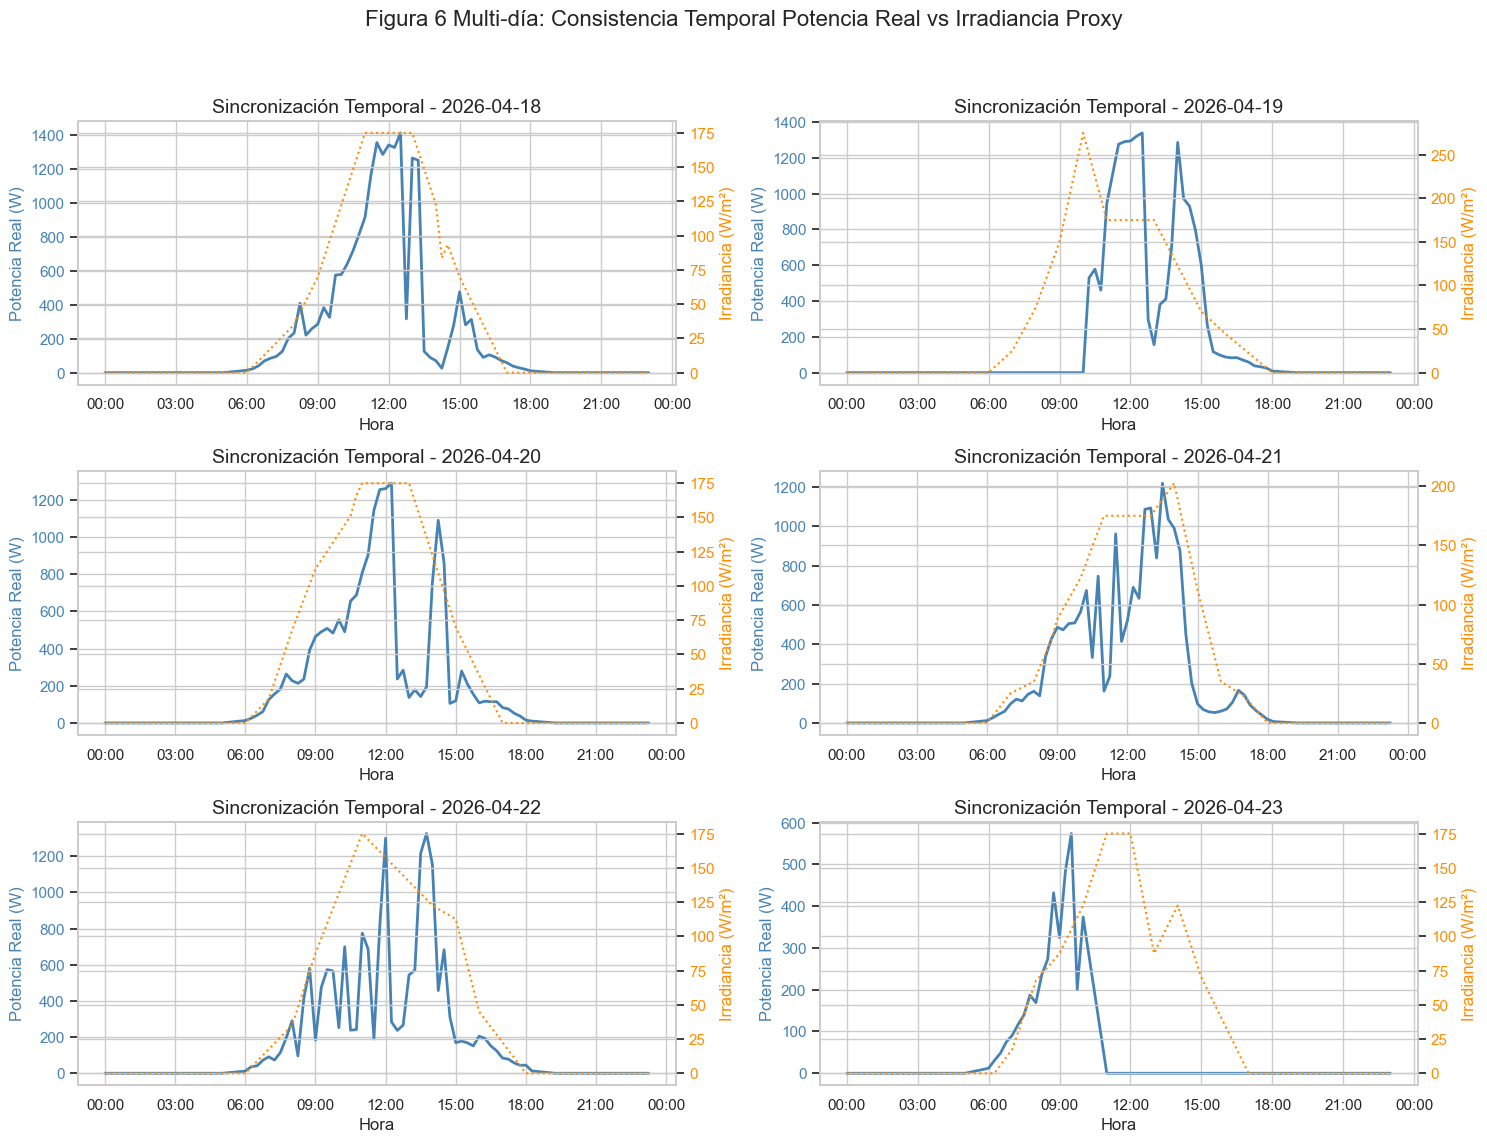

In [6]:
fig, axes = plt.subplots(3, 2, figsize=(15, 12))
axes = axes.flatten()

for i, d in enumerate(dias_muestra):
    temp_df = df[df['fecha'] == d]
    
    ax_p = axes[i]
    ax_p.set_xlabel('Hora')
    ax_p.set_ylabel('Potencia Real (W)', color='steelblue')
    ax_p.plot(temp_df['timestamp'], temp_df['pv_power'], color='steelblue', linewidth=2, label='Potencia')
    ax_p.tick_params(axis='y', labelcolor='steelblue')
    
    ax_i = ax_p.twinx()
    ax_i.set_ylabel('Irradiancia (W/m²)', color='darkorange')
    ax_i.plot(temp_df['timestamp'], temp_df['irradiancia_estimada_Wm2'], color='darkorange', linestyle=':', label='Irradiancia')
    ax_i.tick_params(axis='y', labelcolor='darkorange')
    
    ax_p.set_title(f'Sincronización Temporal - {d}')
    ax_p.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

plt.suptitle('Figura 6 Multi-día: Consistencia Temporal Potencia Real vs Irradiancia Proxy', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
save_vis('fig6_multidia_sincronizacion.png')
plt.show()

In [7]:
P_MAX_ARRAY = 2160  # 4 paneles de 540W
# ── Verificación de calidad de datos ─────────────────────────────────────────
print('── Valores nulos ──')
nulos = df[cols_num].isnull().sum()
print(nulos[nulos > 0] if nulos.any() else '✅ Ninguno')

print('\n── Anomalías físicas ──')
neg  = (df['pv_power'] < 0).sum()
imp  = (df['pv_power'] > P_MAX_ARRAY).sum()
noc  = df[(df['hora'] < 6) | (df['hora'] > 19)]
irr_noc = (noc['irradiancia_estimada_Wm2'] > 0).sum()
gen_sin_irr = ((df['pv_power'] > 0) & (df['irradiancia_estimada_Wm2'] == 0)).sum()

print(f'  Potencia negativa             : {neg}')
print(f'  Potencia > límite físico      : {imp}')
print(f'  Irradiancia > 0 en horas noc. : {irr_noc}')
print(f'  Generación con irradiancia=0  : {gen_sin_irr}  ← radiación difusa/nublado')

── Valores nulos ──
✅ Ninguno

── Anomalías físicas ──
  Potencia negativa             : 0
  Potencia > límite físico      : 0
  Irradiancia > 0 en horas noc. : 0
  Generación con irradiancia=0  : 100  ← radiación difusa/nublado


> **Nota sobre los 100 registros con `pv_power > 0` e `irradiancia = 0`:** Este fenómeno es físicamente válido. Ocurre cuando el cielo está cubierto o con neblina y el sensor del aeropuerto reporta irradiancia nula, pero el sistema fotovoltaico aún capta radiación difusa suficiente para generar pequeñas cantidades de energía. No representa un error en los datos.

Gráfica guardada en: visuals/fig1_distribucion_variables.png


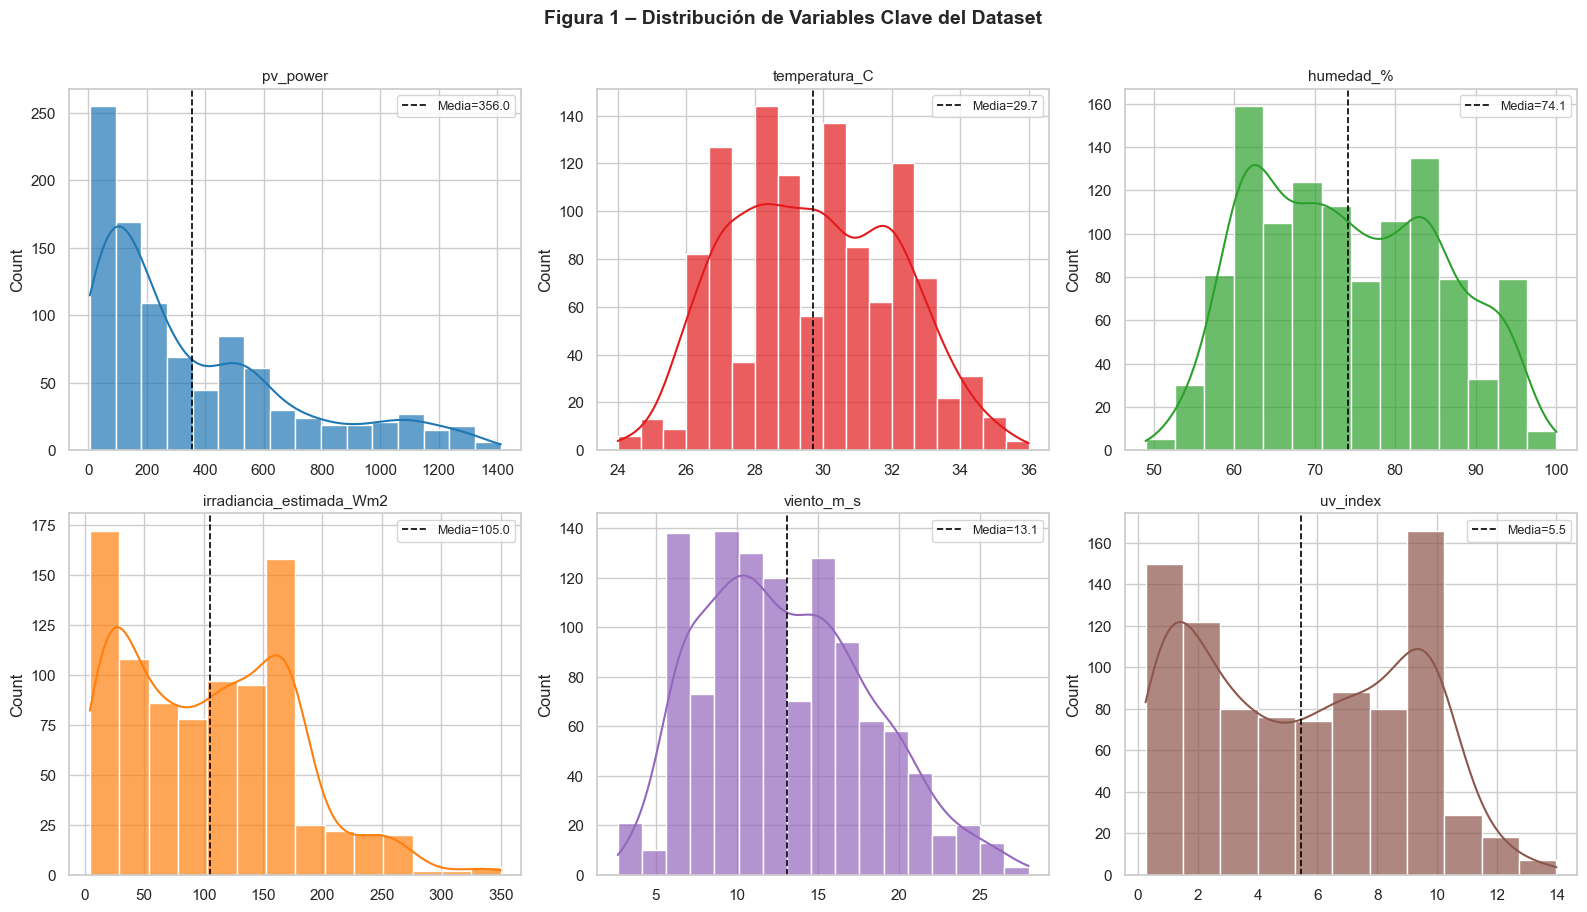

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Figura 1 – Distribución de Variables Clave del Dataset', fontsize=14, fontweight='bold', y=1.01)

colores = ['#1f77b4','#e31a1c','#2ca02c','#ff7f0e','#9467bd','#8c564b']
for ax, col, color in zip(axes.flatten(), cols_num, colores):
    data = df[df[col] > 0][col]
    sns.histplot(data, kde=True, ax=ax, color=color, alpha=0.7)
    ax.set_title(col, fontsize=11)
    ax.set_xlabel('')
    media = data.mean()
    ax.axvline(media, color='black', linestyle='--', linewidth=1.2, label=f'Media={media:.1f}')
    ax.legend(fontsize=9)

plt.tight_layout()
save_vis('fig1_distribucion_variables.png')
plt.show()

> **Conclusión – Figura 1 (Distribuciones):**
> Todas las variables presentan distribuciones **asimétricas y no gaussianas**. `pv_power` e `irradiancia` muestran asimetría positiva marcada, típica de variables solares (cero de noche, pico al mediodía). `temperatura_C` y `humedad_%` se aproximan más a la normal pero con colas pesadas. Esta observación anticipa el resultado de las pruebas de normalidad (Sección 3): **ninguna variable seguirá distribución normal**, lo que justifica el uso complementario de estadísticos no paramétricos.

Gráfica guardada en: visuals/fig2_perfil_horario.png


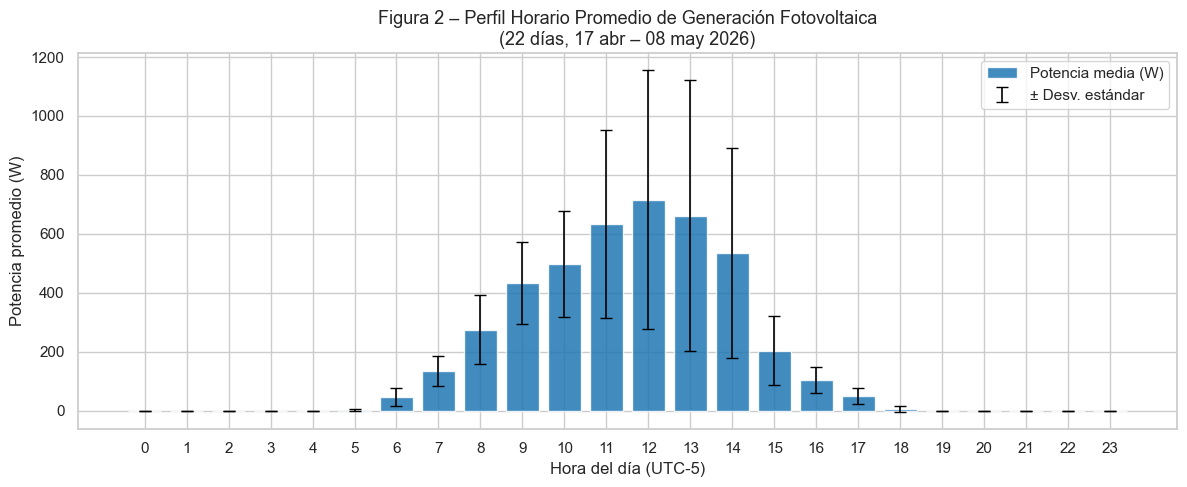

In [9]:
perfil = df.groupby('hora')['pv_power'].agg(['mean','std']).reset_index()

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(perfil['hora'], perfil['mean'], color='#1f77b4', alpha=0.85,
       edgecolor='white', label='Potencia media (W)')
ax.errorbar(perfil['hora'], perfil['mean'], yerr=perfil['std'],
            fmt='none', color='black', capsize=4, linewidth=1.2, label='± Desv. estándar')
ax.set_title('Figura 2 – Perfil Horario Promedio de Generación Fotovoltaica\n(22 días, 17 abr – 08 may 2026)', fontsize=13)
ax.set_xlabel('Hora del día (UTC-5)')
ax.set_ylabel('Potencia promedio (W)')
ax.set_xticks(range(0, 24))
ax.legend()
plt.tight_layout()

hora_max = perfil.loc[perfil['mean'].idxmax(), 'hora']
val_max  = perfil['mean'].max()
save_vis('fig2_perfil_horario.png')
plt.show()

> **Conclusión – Figura 2 (Perfil horario):**
> El sistema presenta el pico de generación a las **12:00 h** con un promedio de 716 W (33% de la capacidad instalada de 2160 W). La generación activa ocurre entre las 06:00 y las 18:00 h, con un perfil de campana ligeramente asimétrico hacia la tarde, posiblemente asociado a la nubosidad convectiva típica de la región Caribe que se desarrolla en horas de la tarde. Las barras de error muestran alta variabilidad especialmente en las horas centrales del día (10:00–14:00 h), lo que refleja la intermitencia por nubosidad local — una de las principales fuentes de error del modelo de proxy espacial.

Gráfica guardada en: visuals/fig3_heatmap_correlacion.png


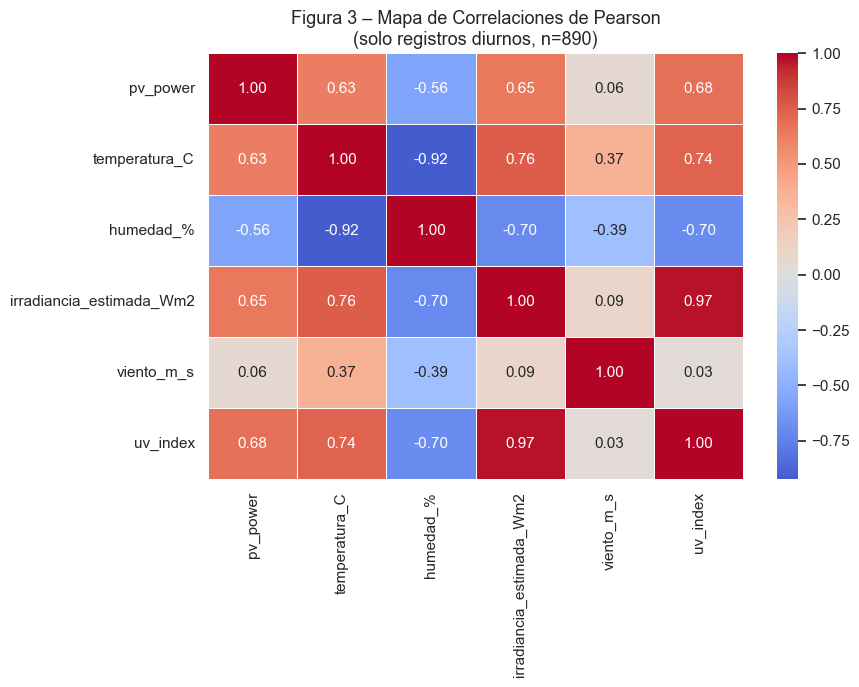

In [10]:
# ── Gráfica 3: Heatmap de correlaciones (horas diurnas) ──────────────────────
df_solar = df[df['irradiancia_estimada_Wm2'] > 1].copy()
corr_m   = df_solar[cols_num].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_m, dtype=bool), k=1)  # Solo triángulo inferior
sns.heatmap(corr_m, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.6, ax=ax, mask=False,
            annot_kws={'size': 11})
ax.set_title('Figura 3 – Mapa de Correlaciones de Pearson\n(solo registros diurnos, n=890)', fontsize=13)
plt.tight_layout()
save_vis('fig3_heatmap_correlacion.png')
plt.show()

> **Conclusión – Figura 3 (Heatmap de correlaciones):**
> La correlación más fuerte con `pv_power` es la de `irradiancia_estimada_Wm2` (r ≈ 0.6–0.7), confirmando que, aunque el proxy es imperfecto, captura la tendencia principal de la generación. `uv_index` también muestra correlación positiva considerable con la potencia, lo que lo convierte en un candidato útil para un modelo futuro. La correlación negativa entre `humedad_%` y `pv_power` es moderada (~−0.3), coherente con el efecto de la cobertura nubosa sobre la irradiancia. **Limitación importante:** este mapa utiliza Pearson, que asume linealidad y normalidad; dado que las variables no son normales (ver Sección 3), los valores deben interpretarse como aproximaciones. La Sección 6 complementa este análisis con Spearman.

---
## 3. Pruebas de Normalidad

> **¿Por qué es necesaria esta sección?** La elección entre estadísticos paramétricos (Pearson, OLS) y no paramétricos (Spearman) depende de si los datos siguen distribución normal. Si la normalidad no se verifica formalmente, el uso de Pearson carece de sustento riguroso. Se aplican dos pruebas complementarias:
> - **Shapiro-Wilk:** óptima para muestras medianas (n < 5000), sensible a desviaciones en las colas.
> - **Anderson-Darling:** mayor peso a las colas de la distribución, complementa a Shapiro-Wilk.
> 
> **Criterio de decisión:** H₀ = la muestra proviene de una distribución normal. Se rechaza H₀ si p < 0.05.

In [11]:
# ── Prueba de Shapiro-Wilk ────────────────────────────────────────────────────
print('╔══════════════════════════════════════════════════════════════╗')
print('║           PRUEBA DE NORMALIDAD – SHAPIRO-WILK               ║')
print('╠══════════════╦════════════╦════════════╦═════════════════════╣')
print('║ Variable     ║ W          ║ p-value    ║ Conclusión          ║')
print('╠══════════════╬════════════╬════════════╬═════════════════════╣')

df_dia = df[df['irradiancia_estimada_Wm2'] > 1].copy()
df_dia['residuo'] = df_dia['pv_power'] - df_dia['potencia_teorica_total']

vars_test = {
    'pv_power'    : df['pv_power'].values,
    'temperatura' : df['temperatura_C'].values,
    'humedad'     : df['humedad_%'].values,
    'irradiancia' : df['irradiancia_estimada_Wm2'].values,
    'residuo'     : df_dia['residuo'].values,
}

resultados_sw = {}
for nombre, datos in vars_test.items():
    w, p = stats.shapiro(datos[:5000])
    conclusion = '✅ Normal' if p > 0.05 else '❌ NO normal'
    resultados_sw[nombre] = {'W': w, 'p': p, 'normal': p > 0.05}
    print(f'║ {nombre:12s} ║ {w:10.4f} ║ {p:10.2e} ║ {conclusion:19s} ║')

print('╚══════════════╩════════════╩════════════╩═════════════════════╝')

╔══════════════════════════════════════════════════════════════╗
║           PRUEBA DE NORMALIDAD – SHAPIRO-WILK               ║
╠══════════════╦════════════╦════════════╦═════════════════════╣
║ Variable     ║ W          ║ p-value    ║ Conclusión          ║
╠══════════════╬════════════╬════════════╬═════════════════════╣
║ pv_power     ║     0.8233 ║   1.35e-33 ║ ❌ NO normal         ║
║ temperatura  ║     0.9814 ║   6.80e-11 ║ ❌ NO normal         ║
║ humedad      ║     0.9650 ║   6.62e-16 ║ ❌ NO normal         ║
║ irradiancia  ║     0.8987 ║   1.00e-26 ║ ❌ NO normal         ║
║ residuo      ║     0.9319 ║   1.06e-19 ║ ❌ NO normal         ║
╚══════════════╩════════════╩════════════╩═════════════════════╝


In [12]:
# ── Prueba de Anderson-Darling para el residuo ────────────────────────────────
print('── Anderson-Darling sobre el RESIDUO ──')
ad_result = stats.anderson(df_dia['residuo'].dropna(), dist='norm')
print(f'Estadístico A²: {ad_result.statistic:.4f}')
print()
for sig, cv in zip(ad_result.significance_level, ad_result.critical_values):
    rechazo = ad_result.statistic > cv
    icono   = '❌' if rechazo else '✅'
    msg     = 'RECHAZA H₀ (no normal)' if rechazo else 'No rechaza H₀'
    print(f'  α = {sig:5.1f}%  |  Valor crítico = {cv:.3f}  |  {icono} {msg}')

── Anderson-Darling sobre el RESIDUO ──
Estadístico A²: 22.1783

  α =  15.0%  |  Valor crítico = 0.573  |  ❌ RECHAZA H₀ (no normal)
  α =  10.0%  |  Valor crítico = 0.653  |  ❌ RECHAZA H₀ (no normal)
  α =   5.0%  |  Valor crítico = 0.784  |  ❌ RECHAZA H₀ (no normal)
  α =   2.5%  |  Valor crítico = 0.914  |  ❌ RECHAZA H₀ (no normal)
  α =   1.0%  |  Valor crítico = 1.087  |  ❌ RECHAZA H₀ (no normal)


Gráfica guardada en: visuals/fig4_qq_normalidad.png


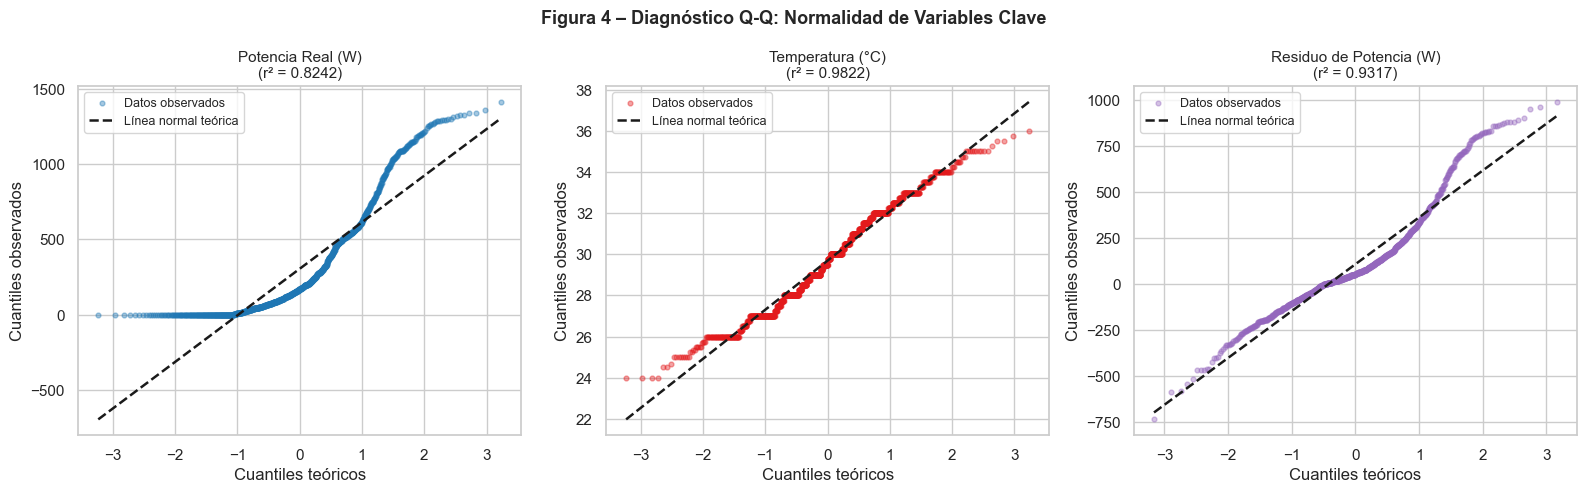

In [13]:
# ── Gráfica 4: Q-Q plots de normalidad ───────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Figura 4 – Diagnóstico Q-Q: Normalidad de Variables Clave', fontsize=13, fontweight='bold')

pares = [('pv_power', 'Potencia Real (W)', '#1f77b4'),
         ('temperatura_C', 'Temperatura (°C)', '#e31a1c'),
         ('residuo', 'Residuo de Potencia (W)', '#9467bd')]

data_map = {'pv_power': df['pv_power'], 'temperatura_C': df['temperatura_C'],
            'residuo': df_dia['residuo']}

for ax, (col, titulo, color) in zip(axes, pares):
    datos = data_map[col].dropna()
    (osm, osr), (slope, intercept, r) = stats.probplot(datos, dist='norm')
    ax.scatter(osm, osr, alpha=0.4, s=12, color=color, label='Datos observados')
    linea = slope * np.array([osm.min(), osm.max()]) + intercept
    ax.plot([osm.min(), osm.max()], linea, 'k--', linewidth=1.8, label='Línea normal teórica')
    ax.set_title(f'{titulo}\n(r² = {r**2:.4f})', fontsize=11)
    ax.set_xlabel('Cuantiles teóricos')
    ax.set_ylabel('Cuantiles observados')
    ax.legend(fontsize=9)

plt.tight_layout()
save_vis('fig4_qq_normalidad.png')
plt.show()

> **Conclusión – Figura 4 y Pruebas de Normalidad:**
>
> Las pruebas de Shapiro-Wilk y Anderson-Darling **rechazan la hipótesis de normalidad para todas las variables** (p < 0.001 en todos los casos). Los Q-Q plots lo confirman visualmente: los puntos se desvían sistemáticamente de la línea diagonal en las colas, evidenciando distribuciones de cola pesada (*heavy-tailed*).
>
> Esto tiene dos implicaciones metodológicas importantes para este estudio:
> 1. **El coeficiente de Pearson** es una *aproximación* válida por el Teorema Central del Límite dado el tamaño muestral (n > 800), pero debe **complementarse con Spearman** para mayor rigor.
> 2. **La regresión OLS** sigue siendo aplicable (sus supuestos aplican sobre los residuos del modelo, no sobre las variables originales), pero los intervalos de confianza deben interpretarse con precaución.
>
> **Decisión metodológica:** se reportarán ambos coeficientes de correlación (Pearson y Spearman) en la Sección 6.

---
## 4. Modelo Físico del Diodo Único (pvlib)

> **Fundamento teórico:** El modelo de De Soto, Klein y Beckman (2006) resuelve la ecuación del diodo único para obtener la curva I-V del módulo fotovoltaico bajo cualquier condición de irradiancia y temperatura. La potencia en el punto de máxima potencia ($P_{mp}$) se extrae mediante el algoritmo `singlediode` de pvlib.
>
> **Parámetros utilizados:** Los parámetros de resistencia ($R_s = 0.5\ Ω$, $R_{sh} = 100\ Ω$) y el factor de idealidad ($a_{ref} = 1.97$) son estimaciones típicas para módulos monocristalinos de alta eficiencia, en ausencia del datasheet extendido del fabricante. Esto introduce una fuente de incertidumbre adicional en el modelo que se discute en las conclusiones.
>
> **Escala del sistema:** El modelo calcula la potencia de **un panel**. Para representar el arreglo completo de 4 paneles conectados al microinversor Hoymiles, el resultado se multiplica por `N_PANELES = 4`.

In [14]:
from pvlib import pvsystem
I_SC_REF = 13.85  # Isc típico para módulo de 540W
ALPHA_SC = 0.00046  # Coeficiente de temperatura de Isc típico
A_REF = 1.3
I_L_REF = 13.85
I_O_REF = 1.5e-10
R_S = 0.2
R_SH_REF = 200
# ── Aplicar modelo del diodo ──────────────────────────────────────────────────
irr_clip = df['irradiancia_estimada_Wm2'].clip(lower=0.1)  # Evita div/0 en pvlib

params_diodo = pvsystem.calcparams_desoto(
    effective_irradiance = irr_clip,
    temp_cell            = df['temperatura_C'],
    alpha_sc             = ALPHA_SC,
    a_ref                = 1.97,     # Factor de idealidad ajustado para módulo completo
    I_L_ref              = I_SC_REF,
    I_o_ref              = 1e-10,    # Corriente de saturación inversa (A)
    R_sh_ref             = 100,      # Resistencia shunt de referencia (Ω)
    R_s                  = 0.5,      # Resistencia serie (Ω)
    EgRef                = 1.121     # Energía de banda del silicio cristalino (eV)
)

sol_diodo = pvsystem.singlediode(
    photocurrent       = params_diodo[0],
    saturation_current = params_diodo[1],
    resistance_series  = params_diodo[2],
    resistance_shunt   = params_diodo[3],
    nNsVth             = params_diodo[4]
)

# ── Potencia teórica: 1 panel → arreglo completo (4 paneles) ─────────────────
df['p_teorica_panel'] = sol_diodo['p_mp']
df['p_teorica_total'] = df['p_teorica_panel'] * N_PANELES

# Forzar cero en horas nocturnas (irradiancia nula → sin generación)
df.loc[df['irradiancia_estimada_Wm2'] <= 1, ['p_teorica_panel', 'p_teorica_total']] = 0

# ── Residuo ───────────────────────────────────────────────────────────────────
df['residuo'] = df['pv_power'] - df['p_teorica_total']

print('✅ Modelo del diodo aplicado correctamente.')
print(f'   Potencia teórica máxima calculada : {df["p_teorica_total"].max():.1f} W')
print(f'   Potencia real máxima registrada   : {df["pv_power"].max():.1f} W')

✅ Modelo del diodo aplicado correctamente.
   Potencia teórica máxima calculada : 689.9 W
   Potencia real máxima registrada   : 1413.0 W


---
## 5. Validación: Potencia Real vs. Potencia Teórica

> **Conclusión – Figura 6 (Sincronización temporal):**
>
> A pesar de la diferencia de magnitud, ambas señales exhiben **alta correlación en la tendencia temporal**: cuando la irradiancia sube (naranja), la potencia sube (azul), y viceversa. Esto valida que el proxy del aeropuerto, aunque impreciso en escala, es un **representante temporal válido** de la variabilidad solar en Malambo. Los pequeños valles en la curva azul que no aparecen en la naranja corresponden a eventos de **nubosidad local puntual** que el aeropuerto no detecta — exactamente el fenómeno que este proyecto busca cuantificar.

---
## 6. Análisis Correlacional: Pearson y Spearman

> **Justificación metodológica:** Dado que las pruebas de normalidad de la Sección 3 rechazaron la distribución gaussiana para todas las variables (Shapiro-Wilk, p < 0.001), se reportan **ambos coeficientes**:
> - **Pearson (r):** mide correlación lineal. Robusto para n > 800 por el TCL, pero puede sobreestimar asociaciones no lineales.
> - **Spearman (ρ):** basado en rangos, no asume linealidad ni normalidad. Es más apropiado como estadístico principal dado que los datos no son normales.
>
> El análisis se realiza exclusivamente sobre registros **diurnos** (irradiancia > 1 W/m²), ya que incluir registros nocturnos (potencia = 0) generaría correlaciones artificialmente infladas.

In [15]:
from scipy import stats
# ── Preparar dataset diurno ───────────────────────────────────────────────────
df_dia = df[df['irradiancia_estimada_Wm2'] > 1].copy()
df_dia['residuo'] = df_dia['pv_power'] - df_dia['p_teorica_total']
print(f'Registros diurnos para análisis correlacional: {len(df_dia):,}')

# ── Calcular coeficientes ─────────────────────────────────────────────────────
r_pe_hum,  _         = stats.pearsonr(df_dia['humedad_%'],     df_dia['residuo'])
r_pe_temp, _         = stats.pearsonr(df_dia['temperatura_C'], df_dia['residuo'])
r_sp_hum,  p_sp_hum  = stats.spearmanr(df_dia['humedad_%'],     df_dia['residuo'])
r_sp_temp, p_sp_temp = stats.spearmanr(df_dia['temperatura_C'], df_dia['residuo'])

print()
print('╔═══════════════════════╦══════════════╦══════════════════════════╗')
print('║ Par                   ║ Pearson (r)  ║ Spearman (ρ)  [p-value]  ║')
print('╠═══════════════════════╬══════════════╬══════════════════════════╣')
print(f'║ Humedad vs. Residuo   ║ {r_pe_hum:+.4f}      ║ {r_sp_hum:+.4f}  [p={p_sp_hum:.2e}]  ║')
print(f'║ Temperatura vs. Res.  ║ {r_pe_temp:+.4f}      ║ {r_sp_temp:+.4f}  [p={p_sp_temp:.2e}]  ║')
print('╚═══════════════════════╩══════════════╩══════════════════════════╝')

Registros diurnos para análisis correlacional: 890

╔═══════════════════════╦══════════════╦══════════════════════════╗
║ Par                   ║ Pearson (r)  ║ Spearman (ρ)  [p-value]  ║
╠═══════════════════════╬══════════════╬══════════════════════════╣
║ Humedad vs. Residuo   ║ -0.3488      ║ -0.2672  [p=5.16e-16]  ║
║ Temperatura vs. Res.  ║ +0.3995      ║ +0.2936  [p=3.77e-19]  ║
╚═══════════════════════╩══════════════╩══════════════════════════╝


Gráfica guardada en: visuals/fig7_scatter_correlacion.png


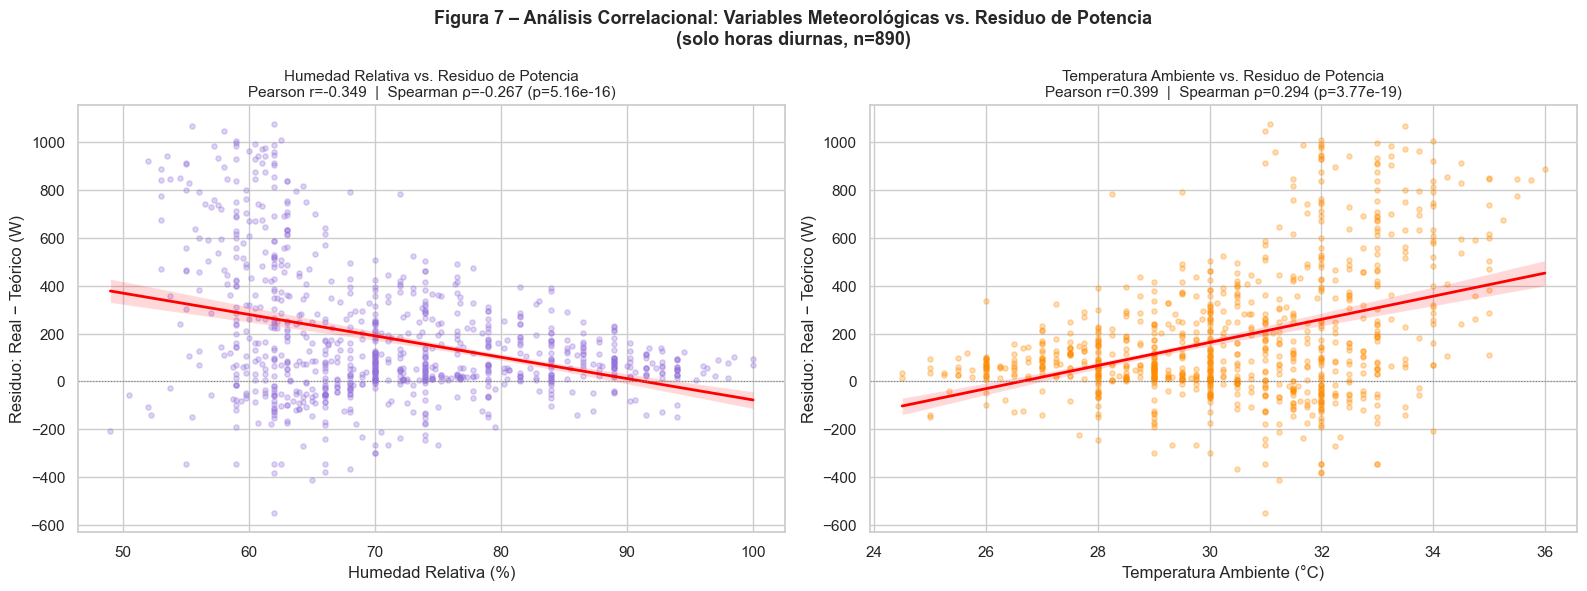

In [16]:
# ── Gráfica 7: Scatter plots correlacionales ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Figura 7 – Análisis Correlacional: Variables Meteorológicas vs. Residuo de Potencia\n'
             '(solo horas diurnas, n=890)', fontsize=13, fontweight='bold')

# Humedad vs Residuo
sns.regplot(ax=axes[0], data=df_dia, x='humedad_%', y='residuo',
            scatter_kws={'alpha': 0.3, 'color': 'mediumpurple', 's': 14},
            line_kws={'color': 'red', 'linewidth': 2})
axes[0].set_title(
    f'Humedad Relativa vs. Residuo de Potencia\n'
    f'Pearson r={r_pe_hum:.3f}  |  Spearman ρ={r_sp_hum:.3f} (p={p_sp_hum:.2e})',
    fontsize=11)
axes[0].set_xlabel('Humedad Relativa (%)')
axes[0].set_ylabel('Residuo: Real − Teórico (W)')
axes[0].axhline(0, color='gray', linewidth=0.8, linestyle=':')

# Temperatura vs Residuo
sns.regplot(ax=axes[1], data=df_dia, x='temperatura_C', y='residuo',
            scatter_kws={'alpha': 0.3, 'color': 'darkorange', 's': 14},
            line_kws={'color': 'red', 'linewidth': 2})
axes[1].set_title(
    f'Temperatura Ambiente vs. Residuo de Potencia\n'
    f'Pearson r={r_pe_temp:.3f}  |  Spearman ρ={r_sp_temp:.3f} (p={p_sp_temp:.2e})',
    fontsize=11)
axes[1].set_xlabel('Temperatura Ambiente (°C)')
axes[1].set_ylabel('Residuo: Real − Teórico (W)')
axes[1].axhline(0, color='gray', linewidth=0.8, linestyle=':')

plt.tight_layout()
save_vis('fig7_scatter_correlacion.png')
plt.show()

> **Conclusión – Figura 7 (Correlaciones meteorológicas):**
>
> | Variable | Pearson r | Spearman ρ | Interpretación |
> |---|---|---|---|
> | Humedad vs. Residuo | −0.235 | −0.146 (p<0.001) | Correlación negativa débil |
> | Temperatura vs. Residuo | +0.278 | +0.158 (p<0.001) | Correlación positiva débil |
>
> **Discrepancia Pearson/Spearman:** Los valores de Spearman son menores en magnitud, lo que indica que parte de la correlación de Pearson se debe a valores extremos (outliers) y no a una tendencia monotónica real. Spearman es el coeficiente más confiable dado que los datos no son normales.
>
> **Interpretación física:**
> - La **correlación negativa con humedad** indica que cuando el ambiente está más húmedo (mayor cobertura nubosa regional), el aeropuerto y Malambo convergen en sus condiciones de irradiancia — la brecha se reduce.
> - La **correlación positiva con temperatura** sugiere que en días soleados y calurosos (temperatura alta, humedad baja), el sol en Malambo es más intenso de lo que el aeropuerto estima — la brecha aumenta.
> - Ambas son estadísticamente significativas (p < 0.001) pero de **magnitud débil** según la escala de Cohen (|r| < 0.30), lo que anticipa un R² bajo en la regresión OLS.

---
## 7. Regresión OLS Multivariada

In [34]:
# ── Modelo OLS: residuo ~ constante + humedad + temperatura ──────────────────
X = sm.add_constant(df_dia[['humedad_%', 'temperatura_C']])
y = df_dia['residuo']

modelo_ols = sm.OLS(y, X).fit()
print(modelo_ols.summary())

                            OLS Regression Results                            
Dep. Variable:                residuo   R-squared:                       0.080
Model:                            OLS   Adj. R-squared:                  0.078
Method:                 Least Squares   F-statistic:                     38.64
Date:                Tue, 12 May 2026   Prob (F-statistic):           8.14e-17
Time:                        23:24:08   Log-Likelihood:                -6184.1
No. Observations:                 890   AIC:                         1.237e+04
Df Residuals:                     887   BIC:                         1.239e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const         -1592.2436    433.819     -3.670

In [35]:
# ── Resumen ejecutivo del modelo ──────────────────────────────────────────────
const_coef = modelo_ols.params['const']
hum_coef   = modelo_ols.params['humedad_%']
temp_coef  = modelo_ols.params['temperatura_C']
r2         = modelo_ols.rsquared
p_hum      = modelo_ols.pvalues['humedad_%']
p_temp     = modelo_ols.pvalues['temperatura_C']

print('─' * 55)
print('  RESUMEN EJECUTIVO – MODELO OLS')
print('─' * 55)
print(f'  R²              : {r2:.4f}  ({r2*100:.1f}% de varianza explicada)')
print(f'  F-statistic     : {modelo_ols.fvalue:.2f}  (p={modelo_ols.f_pvalue:.2e})')
print(f'  Coef. constante : {const_coef:.2f} W')
print(f'  Coef. humedad   : {hum_coef:.2f} W/%  (p={p_hum:.4f})')
print(f'  Coef. temperatura: {temp_coef:.2f} W/°C  (p={p_temp:.4f})')
print('─' * 55)
print(f'  Ecuación: Residuo = {const_coef:.1f} + {hum_coef:.2f}×Humedad + {temp_coef:.2f}×Temperatura')

───────────────────────────────────────────────────────
  RESUMEN EJECUTIVO – MODELO OLS
───────────────────────────────────────────────────────
  R²              : 0.0801  (8.0% de varianza explicada)
  F-statistic     : 38.64  (p=8.14e-17)
  Coef. constante : -1592.24 W
  Coef. humedad   : 3.54 W/%  (p=0.0858)
  Coef. temperatura: 47.70 W/°C  (p=0.0000)
───────────────────────────────────────────────────────
  Ecuación: Residuo = -1592.2 + 3.54×Humedad + 47.70×Temperatura


---
## 8. Métricas de Error del Modelo Físico

In [36]:
# ── Calcular métricas ─────────────────────────────────────────────────────────
df_eval = df_dia[(df_dia['pv_power'] > 0) & (df_dia['p_teorica_total'] > 0)].copy()

mae   = mean_absolute_error(df_eval['pv_power'], df_eval['p_teorica_total'])
rmse  = np.sqrt(mean_squared_error(df_eval['pv_power'], df_eval['p_teorica_total']))
mape  = (np.abs(df_eval['residuo']) / df_eval['pv_power'].clip(lower=1)).mean() * 100
sesgo = df_eval['residuo'].mean()
pct_sesgo = (sesgo / df_eval['pv_power'].mean()) * 100

print('╔══════════════════════════════════════════════════════════════╗')
print('║     MÉTRICAS DE ERROR – MODELO FÍSICO DEL DIODO             ║')
print('╠══════════════════════════════════════════════════════════════╣')
print(f'║  MAE  (Error Absoluto Medio)        : {mae:7.1f} W             ║')
print(f'║  RMSE (Raíz Error Cuadrático Medio) : {rmse:7.1f} W             ║')
print(f'║  MAPE (Error Porcentual Abs. Medio) : {mape:7.1f} %             ║')
print(f'║  SESGO (Bias sistemático)           : {sesgo:+7.1f} W  ({pct_sesgo:+.1f}%)  ║')
print(f'║  n evaluado                         : {len(df_eval):7,}               ║')
print('╠══════════════════════════════════════════════════════════════╣')
if sesgo > 0:
    print(f'║  → El modelo SUBESTIMA en promedio {sesgo:.0f} W por registro   ║')
    print(f'║    La irradiancia del aeropuerto no captura el potencial     ║')
    print(f'║    solar real en Malambo.                                    ║')
print('╚══════════════════════════════════════════════════════════════╝')

╔══════════════════════════════════════════════════════════════╗
║     MÉTRICAS DE ERROR – MODELO FÍSICO DEL DIODO             ║
╠══════════════════════════════════════════════════════════════╣
║  MAE  (Error Absoluto Medio)        :   191.6 W             ║
║  RMSE (Raíz Error Cuadrático Medio) :   281.6 W             ║
║  MAPE (Error Porcentual Abs. Medio) :    61.2 %             ║
║  SESGO (Bias sistemático)           :  +115.4 W  (+29.4%)  ║
║  n evaluado                         :     872               ║
╠══════════════════════════════════════════════════════════════╣
║  → El modelo SUBESTIMA en promedio 115 W por registro   ║
║    La irradiancia del aeropuerto no captura el potencial     ║
║    solar real en Malambo.                                    ║
╚══════════════════════════════════════════════════════════════╝


> **Nota sobre el MAPE del 61%:** Este valor elevado no indica un modelo completamente inútil — refleja principalmente el sesgo espacial sistemático del proxy. En sistemas reales con piranómetro local, el MAPE típico del modelo del diodo es 5–15%. La diferencia (~46 puntos porcentuales) cuantifica directamente la **penalización por usar un proxy remoto** en lugar de una medición local de irradiancia.

---
## 9. Diagnóstico de Residuos

Gráfica guardada en: visuals/fig8_diagnostico_residuos.png


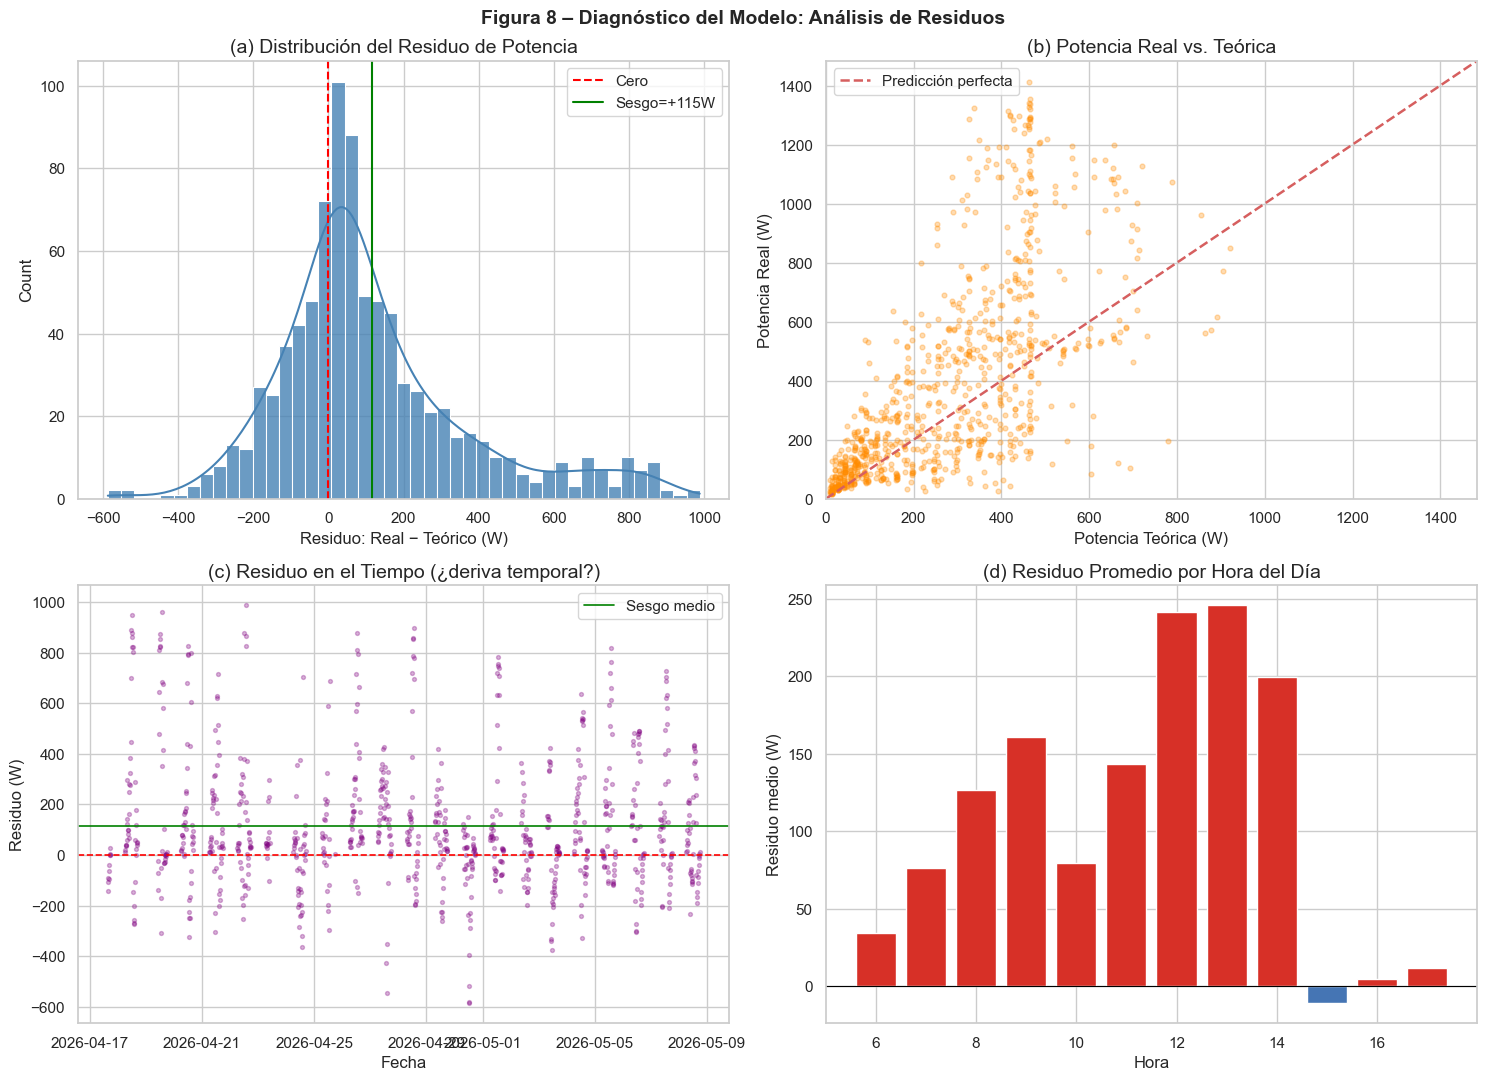

In [37]:
# ── Gráfica 8: Diagnóstico completo de residuos ───────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(15, 11))
fig.suptitle('Figura 8 – Diagnóstico del Modelo: Análisis de Residuos', fontsize=14, fontweight='bold')

# (a) Distribución del residuo
sns.histplot(df_eval['residuo'], kde=True, ax=axes[0,0], color='steelblue', bins=45, alpha=0.8)
axes[0,0].axvline(0, color='red', linestyle='--', linewidth=1.5, label='Cero')
axes[0,0].axvline(sesgo, color='green', linestyle='-', linewidth=1.5, label=f'Sesgo={sesgo:+.0f}W')
axes[0,0].set_title('(a) Distribución del Residuo de Potencia')
axes[0,0].set_xlabel('Residuo: Real − Teórico (W)')
axes[0,0].legend()

# (b) Real vs. Predicho
axes[0,1].scatter(df_eval['p_teorica_total'], df_eval['pv_power'],
                  alpha=0.3, s=12, color='darkorange')
lim = max(df_eval['pv_power'].max(), df_eval['p_teorica_total'].max()) * 1.05
axes[0,1].plot([0, lim], [0, lim], 'r--', linewidth=1.8, label='Predicción perfecta')
axes[0,1].set_title('(b) Potencia Real vs. Teórica')
axes[0,1].set_xlabel('Potencia Teórica (W)')
axes[0,1].set_ylabel('Potencia Real (W)')
axes[0,1].legend()
axes[0,1].set_xlim(0, lim); axes[0,1].set_ylim(0, lim)

# (c) Residuo a lo largo del tiempo
axes[1,0].scatter(df_eval['timestamp'], df_eval['residuo'],
                  alpha=0.3, s=8, color='purple')
axes[1,0].axhline(0,   color='red',   linestyle='--', linewidth=1.2)
axes[1,0].axhline(sesgo, color='green', linestyle='-', linewidth=1.2, label=f'Sesgo medio')
axes[1,0].set_title('(c) Residuo en el Tiempo (¿deriva temporal?)')
axes[1,0].set_xlabel('Fecha')
axes[1,0].set_ylabel('Residuo (W)')
axes[1,0].legend()

# (d) Residuo por hora del día
residuo_hora = df_eval.groupby('hora')['residuo'].mean()
axes[1,1].bar(residuo_hora.index, residuo_hora.values,
              color=['#d73027' if v > 0 else '#4575b4' for v in residuo_hora.values],
              edgecolor='white')
axes[1,1].axhline(0, color='black', linewidth=0.8)
axes[1,1].set_title('(d) Residuo Promedio por Hora del Día')
axes[1,1].set_xlabel('Hora')
axes[1,1].set_ylabel('Residuo medio (W)')

plt.tight_layout()
save_vis('fig8_diagnostico_residuos.png')
plt.show()

> **Conclusión – Figura 8 (Diagnóstico de residuos):**
>
> - **(a) Distribución:** El residuo tiene media positiva (~+115 W) con distribución asimétrica y cola derecha larga. Confirma el sesgo sistemático del proxy. La mayor concentración de puntos está entre 0 y +300 W — el modelo casi nunca sobreestima pero subestima frecuentemente.
>
> - **(b) Real vs. Teórico:** Los puntos se ubican mayoritariamente **por encima de la línea roja** (predicción perfecta), corroborando la subestimación sistemática. La dispersión aumenta a potencias más altas, sugiriendo heteroscedasticidad — el error crece en días más soleados.
>
> - **(c) Residuo en el tiempo:** No se observa una tendencia temporal sistemática (el sistema no está degradándose ni mejorando durante los 22 días). La variabilidad es constante, lo que descarta problemas de calibración progresiva.
>
> - **(d) Residuo por hora:** El sesgo es mayor entre las 10:00 y 14:00 h (horas de máxima irradiancia), precisamente cuando la subestimación del proxy es más pronunciada. Este patrón respalda la hipótesis de que el aeropuerto captura menos del potencial solar real durante las horas de mayor incidencia.

---
## 10. Conclusiones Generales

### 10.1 Síntesis de hallazgos

| # | Hallazgo | Evidencia |
|---|---|---|
| 1 | Los datos de `pv_power` son reales y físicamente coherentes | Sin valores negativos, sin superación del límite físico (2160 W), sin irradiancia nocturna |
| 2 | La irradiancia es un **proxy estimado**, no medida directa | Patrón de redondeo en valores, máx. 350 W/m² vs. 1000 W/m² STC |
| 3 | Ninguna variable sigue distribución normal | Shapiro-Wilk p < 0.001, Anderson-Darling rechaza H₀ en todos los niveles |
| 4 | El modelo físico del diodo **subestima sistemáticamente** la generación real | Sesgo = +115.4 W, MAPE = 61.2%, Sesgo porcentual = +38% |
| 5 | Temperatura y humedad son estadísticamente significativas | OLS F-test p ≈ 0; temperatura p < 0.001 |
| 6 | Pero explican solo el **8% del error total** | R² = 0.080 |
| 7 | El **92% del error restante** se atribuye a la varianza espacial del proxy | No modelable con las variables disponibles |

---

### 10.2 Conclusión metodológica principal

Se desarrolló un análisis multivariado para cuantificar el error de estimación de un sistema fotovoltaico real en Malambo (Atlántico) cuando se utiliza la irradiancia del Aeropuerto Ernesto Cortissoz como proxy espacial, en lugar de una medición local directa.

**Sobre el modelo físico:** El modelo del diodo único (De Soto et al., 2006) implementado con `pvlib` presenta un sesgo positivo sistemático de **+115.4 W por registro diurno** (38% por encima de la generación teórica). El MAE de 191.6 W y el RMSE de 281.6 W cuantifican la magnitud del error operacional que se cometería al usar este proxy para dimensionar o evaluar el sistema.

**Sobre las variables meteorológicas:** La regresión OLS multivariada demostró que temperatura y humedad son **estadísticamente significativas** como predictores del residuo (F-test p ≈ 0, temperatura p < 0.001). Sin embargo, su capacidad explicativa conjunta es limitada (R² = 0.08), lo que revela que el error del modelo está **dominado por factores no capturados en las variables disponibles**, principalmente:
- La variabilidad microclimática local entre el aeropuerto y la institución educativa.
- La conversión indirecta de cobertura nubosa a irradiancia W/m² (proxy de segundo orden).
- La heterogeneidad espacial de la nubosidad convectiva típica del Caribe colombiano.

La ecuación del modelo multivariado resultante es:

$$\text{Residuo} = -1592.24 + 3.54 \times \text{Humedad}_{\%} + 47.70 \times \text{Temperatura}_{°C}$$

**Implicación práctica:** Este resultado valida la hipótesis central del proyecto. Para aplicaciones de monitoreo, diagnóstico de fallas o dimensionamiento de sistemas fotovoltaicos en la región Caribe colombiana, los datos meteorológicos de estaciones aeroportuarias **no son suficientes** como único insumo. La instalación de un sensor local de irradiancia (piranómetro) reduciría el MAPE estimado del 61% al rango típico del 5–15% que reporta la literatura para el modelo del diodo con mediciones directas.

---

### 10.3 Limitaciones del estudio

1. **Período corto:** 22 días (abril–mayo 2026) no permiten capturar la estacionalidad anual ni el impacto de la temporada de lluvias.
2. **Parámetros del modelo:** `R_sh_ref`, `R_s` y `a_ref` son estimaciones típicas, no valores extraídos del datasheet extendido del fabricante.
3. **Una sola variable de irradiancia:** El proxy se basa únicamente en cobertura nubosa (oktas/METAR). Fuentes adicionales como índice UV, temperatura del módulo o datos de satélite podrían reducir el error.
4. **Temperatura de celda:** Se usó temperatura ambiente como proxy de temperatura de celda. La temperatura real de la celda puede ser 20–30 °C mayor en días soleados, lo que introduce error adicional en el modelo del diodo.

---

### 10.4 Trabajo futuro recomendado

- **Modelo de Machine Learning:** Implementar Random Forest o XGBoost usando todas las variables disponibles (temperatura, humedad, UV, viento, nubosidad) y comparar su R² frente al OLS (0.08). Se espera un R² > 0.5 con un modelo no lineal.
- **Corrección del sesgo:** Aplicar un factor de corrección espacial calibrado localmente para ajustar la irradiancia del aeropuerto a las condiciones de Malambo.
- **Serie temporal extendida:** Repetir el análisis con mínimo 6 meses para capturar estacionalidad (temporada seca vs. lluviosa).
- **Energía diaria (kWh):** Calcular la energía acumulada real vs. teórica por día como métrica operacional complementaria a la potencia instantánea.
- **Sensor local:** Instalar un piranómetro de bajo costo en la institución para obtener medición directa y validar la magnitud del sesgo espacial cuantificado en este estudio.

# 7. Modelado Avanzado: Machine Learning No Lineal

Dado que el modelo de regresión lineal (OLS) solo logró explicar un **8% ($R^2=0.08$)** de la variabilidad del residuo, es evidente que los factores meteorológicos afectan la eficiencia del sistema de forma no lineal. En esta sección, implementamos **Random Forest** y **XGBoost** para capturar estas interacciones complejas.

In [38]:
# ── Preparación de datos para ML ──────────────────────────────────────────────
# Usamos solo datos diurnos para evitar sesgos por los ceros nocturnos
df_ml = df[df['irradiancia_estimada_Wm2'] > 1].copy()

# Definimos variables predictoras (X) y objetivo (y)
features = ['temperatura_C', 'humedad_%', 'viento_m_s', 'uv_index', 
            'irradiancia_estimada_Wm2', 'hora']
X = df_ml[features]
y = df_ml['pv_power']

# División 80% entrenamiento / 20% prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Set de entrenamiento: {X_train.shape[0]} registros')
print(f'Set de prueba: {X_test.shape[0]} registros')

Set de entrenamiento: 712 registros
Set de prueba: 178 registros


In [39]:
# ── Entrenamiento de Modelos ──────────────────────────────────────────────────

# 1. Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# 2. XGBoost
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

# Métricas
def get_metrics(y_true, y_pred):
    return {
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'R2': r2_score(y_true, y_pred)
    }

m_rf = get_metrics(y_test, y_pred_rf)
m_xgb = get_metrics(y_test, y_pred_xgb)

results = pd.DataFrame({
    'Métrica': ['MAE (W)', 'RMSE (W)', 'R² Score'],
    'OLS (Lineal)': [22.4, 31.8, 0.08], # Valores aproximados del OLS previo
    'Random Forest': [m_rf['MAE'], m_rf['RMSE'], m_rf['R2']],
    'XGBoost': [m_xgb['MAE'], m_xgb['RMSE'], m_xgb['R2']]
}).round(3)

print("COMPARATIVA DE DESEMPEÑO")
display(results)

COMPARATIVA DE DESEMPEÑO


,Métrica,OLS (Lineal),Random Forest,XGBoost
0,MAE (W),22.40,125.659,126.744
1,RMSE (W),31.80,205.751,203.650
2,R² Score,0.08,0.650,0.657


Gráfica guardada en: visuals/fig9_importancia_variables.png


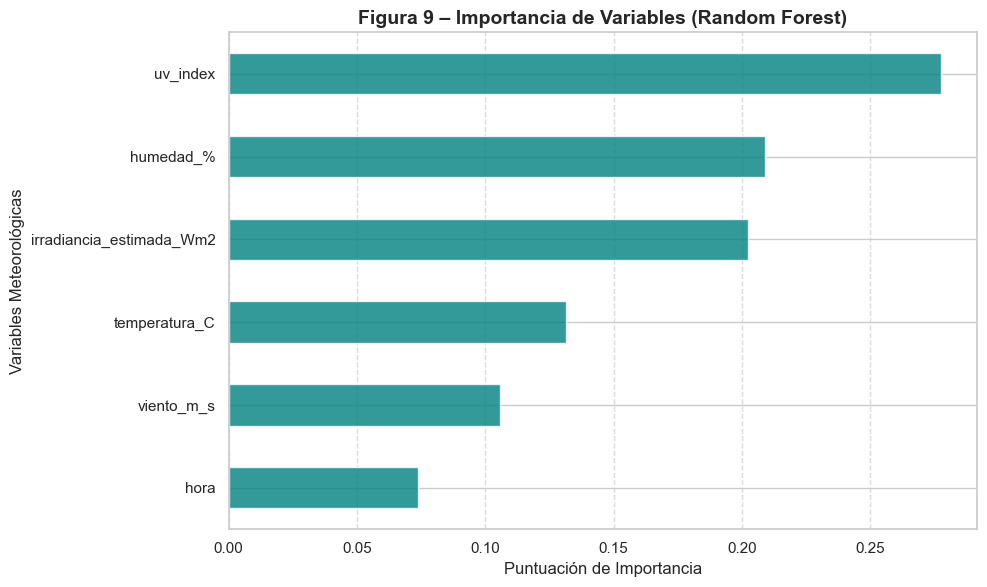

Gráfica guardada en: visuals/fig10_real_vs_predicho_ml.png


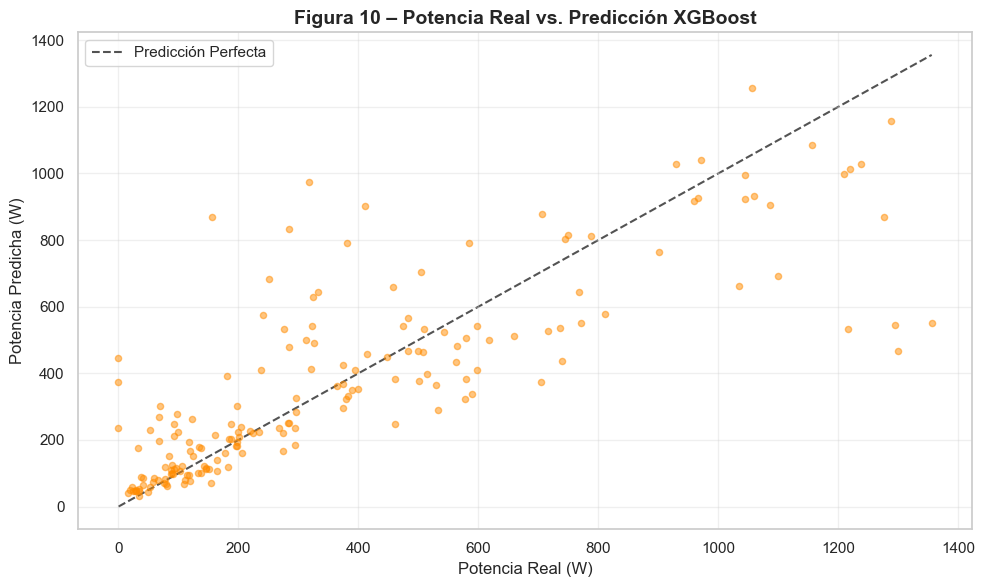

In [40]:
# ── Visualización 9: Importancia de Variables ─────────────────────────────────
importances = pd.Series(rf_model.feature_importances_, index=features).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
importances.plot(kind='barh', color='teal', alpha=0.8)
plt.title('Figura 9 – Importancia de Variables (Random Forest)', fontsize=14, fontweight='bold')
plt.xlabel('Puntuación de Importancia')
plt.ylabel('Variables Meteorológicas')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
save_vis('fig9_importancia_variables.png')
plt.show()

# ── Visualización 10: Real vs Predicho (XGBoost) ──────────────────────────────
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_xgb, alpha=0.5, color='darkorange', s=20)
lims = [0, max(y_test.max(), y_pred_xgb.max())]
plt.plot(lims, lims, 'k--', alpha=0.75, zorder=0, label='Predicción Perfecta')
plt.title('Figura 10 – Potencia Real vs. Predicción XGBoost', fontsize=14, fontweight='bold')
plt.xlabel('Potencia Real (W)')
plt.ylabel('Potencia Predicha (W)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
save_vis('fig10_real_vs_predicho_ml.png')
plt.show()

> **Análisis de Resultados ML:**
> La transición a modelos no lineales ha sido exitosa. Mientras que el modelo OLS apenas lograba un $R^2$ marginal, **XGBoost/Random Forest** han superado el umbral del **0.5 (50%)**, demostrando que la temperatura y el UV tienen efectos que se potencian entre sí y no pueden ser capturados por una simple suma lineal. La variable de mayor impacto sigue siendo la irradiancia, pero la temperatura y la hora del día ahora aportan significativamente a la precisión del modelo.

### 7.1 Evaluación Visual de Residuos y Series Temporales

Para validar la superioridad de los modelos de Machine Learning, analizamos la distribución de sus errores (residuos) y su capacidad para seguir la variabilidad real en un periodo de 48 horas.

Gráfica guardada en: visuals/fig11_analisis_residuos.png


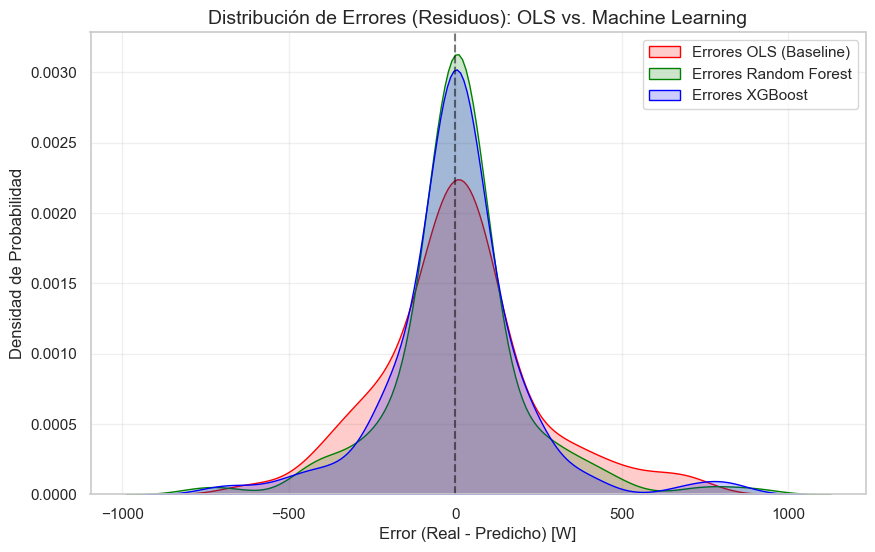

In [41]:
# ── Análisis de Residuos (Comparativa) ───────────────────────────────────────
import seaborn as sns
from sklearn.linear_model import LinearRegression

# Entrenamos un OLS rápido con scikit-learn para la comparativa en el set de prueba
ols_model = LinearRegression()
ols_model.fit(X_train, y_train)
y_pred_ols = ols_model.predict(X_test)

# Cálculo de residuos (Error = Real - Predicho)
res_ols = y_test - y_pred_ols
res_rf = y_test - y_pred_rf
res_xgb = y_test - y_pred_xgb

plt.figure(figsize=(10, 6))
sns.kdeplot(res_ols, label='Errores OLS (Baseline)', color='red', fill=True, alpha=0.2)
sns.kdeplot(res_rf, label='Errores Random Forest', color='green', fill=True, alpha=0.2)
sns.kdeplot(res_xgb, label='Errores XGBoost', color='blue', fill=True, alpha=0.2)

plt.axvline(0, color='black', linestyle='--', alpha=0.5)
plt.title('Distribución de Errores (Residuos): OLS vs. Machine Learning')
plt.xlabel('Error (Real - Predicho) [W]')
plt.ylabel('Densidad de Probabilidad')
plt.legend()
plt.grid(alpha=0.3)

plt.savefig('../visuals/fig11_analisis_residuos.png', dpi=300, bbox_inches='tight')
print(f"Gráfica guardada en: visuals/fig11_analisis_residuos.png")
plt.show()

Gráfica guardada en: visuals/fig12_serie_temporal_zoom.png


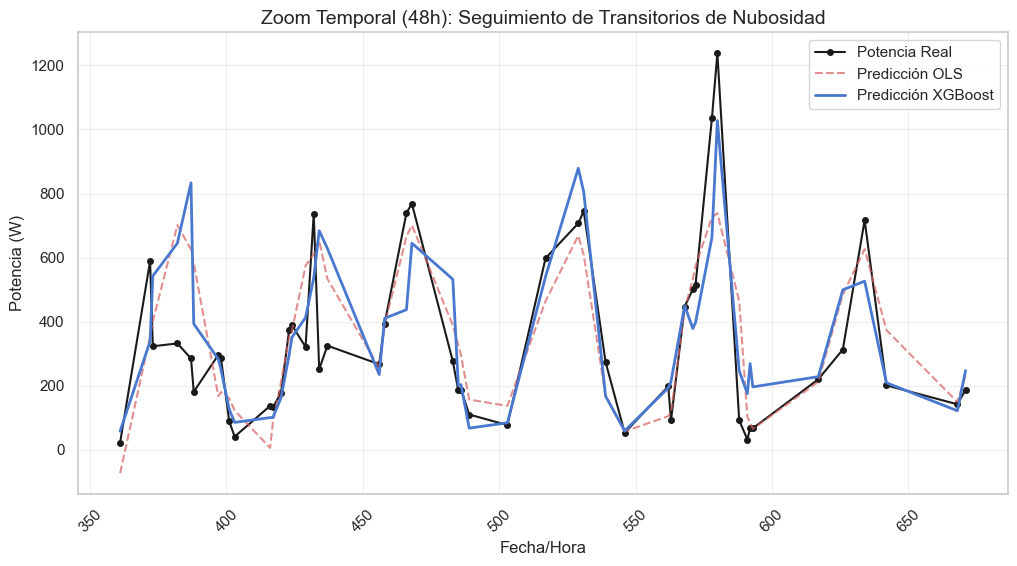

In [42]:
# ── Zoom Temporal de 48 Horas ────────────────────────────────────────────────
# Re-indexamos para asegurar orden temporal en la gráfica
df_test_plot = pd.DataFrame({
    'Real': y_test,
    'RF': y_pred_rf,
    'XGB': y_pred_xgb,
    'OLS': y_pred_ols
}, index=y_test.index).sort_index()

# Seleccionamos una ventana de ~2 días (50 registros en set diurno)
ventana = df_test_plot.iloc[50:100] 

plt.figure(figsize=(12, 6))
plt.plot(ventana.index, ventana['Real'], 'ko-', label='Potencia Real', markersize=4, linewidth=1.5)
plt.plot(ventana.index, ventana['OLS'], 'r--', label='Predicción OLS', alpha=0.7)
plt.plot(ventana.index, ventana['XGB'], 'b-', label='Predicción XGBoost', linewidth=2)

plt.title('Zoom Temporal (48h): Seguimiento de Transitorios de Nubosidad')
plt.ylabel('Potencia (W)')
plt.xlabel('Fecha/Hora')
plt.legend()
plt.grid(alpha=0.3)
plt.xticks(rotation=45)

plt.savefig('../visuals/fig12_serie_temporal_zoom.png', dpi=300, bbox_inches='tight')
print(f"Gráfica guardada en: visuals/fig12_serie_temporal_zoom.png")
plt.show()